In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
from pathlib import Path
# Procura a raiz do projeto (pasta que contém `src`) subindo na arvore
def find_project_root(start: Path = Path.cwd()) -> Path:
    for p in [start] + list(start.parents):
        if (p / 'src').is_dir():
            return p
    return start
proj_root = str(find_project_root())
if proj_root not in sys.path:
    sys.path.insert(0, proj_root)
print('Project root added to sys.path:', proj_root)

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from src.preprocessing import SavgolFilter, SNV, make_savgol, make_scaler, make_snv
from src.utils import extrair_numero
from src.models import PLSDAClassifier, PLSDAMulticlass

Project root added to sys.path: c:\Users\Pedro\Downloads\LIBS_NEW


In [4]:
from src.config import *

list_dirs()


BASE_DIR:  C:\Users\Pedro\Downloads\LIBS_NEW 
DATA_DIR:  C:\Users\Pedro\Downloads\LIBS_NEW\dataset 
MODELS_DIR:  C:\Users\Pedro\Downloads\LIBS_NEW\models 
PLOTS_DIR: C:\Users\Pedro\Downloads\LIBS_NEW\plots


In [7]:
laser = 266
output_models = f'{MODELS_DIR}/models_groupkfold/laser{laser}'
output_plots = f'{PLOTS_DIR}/plots_groupkfold/laser{laser}'
output_plots

'C:\\Users\\Pedro\\Downloads\\LIBS_NEW\\plots/plots_groupkfold/laser266'

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
from pathlib import Path
# Procura a raiz do projeto (pasta que contém `src`) subindo na arvore
def find_project_root(start: Path = Path.cwd()) -> Path:
    for p in [start] + list(start.parents):
        if (p / 'src').is_dir():
            return p
    return start
proj_root = str(find_project_root())
if proj_root not in sys.path:
    sys.path.insert(0, proj_root)
print('Project root added to sys.path:', proj_root)

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from src.preprocessing import SavgolFilter, SNV, make_savgol, make_scaler, make_snv
from src.utils import extrair_numero
from src.models import PLSDAClassifier, PLSDAMulticlass
from src.config import *

laser = int(input('Qual laser utilizado? 266, 532 ou 1064\n'))

if laser not in [532, 1064, 266]:
    raise ValueError('O valor deve ser 266, 532 ou 1064')

print('\nLendo dataset...')
file_path = Path(proj_root) / f'dataset/merged_inoa_full_data_{laser}.dat'

df = pd.read_csv(file_path, sep=';', header=None)

y_raw = df.iloc[0, 1:].values.astype(str)
X_full = df.iloc[1:, 1:].values.astype(float).T

extra_a_labels_266 = {
    'Pilao_sample',
    'Evolutto_sample',
    'Do_Ponto_sample',
    'America_sample',
    'Coamo_sample',
}

X = []
y = []
groups = []

for xi, yi in zip(X_full, y_raw):
    num = extrair_numero(yi)
    if laser == 266:
        if (yi.startswith('A') and num is not None and num <= 12) or yi in extra_a_labels_266:
            X.append(xi)
            y.append('A')
            groups.append(yi)
        elif yi.startswith('R') and num is not None and num <= 9:
            X.append(xi)
            y.append('R')
            groups.append(yi)
    elif laser == 532:
        if yi.startswith('A') and num is not None and num <= 8:
            X.append(xi)
            y.append('A')
            groups.append(yi)
        elif yi.startswith('R') and num is not None and num <= 8:
            X.append(xi)
            y.append('R')
            groups.append(yi)
    else:
        if yi.startswith('A') and num is not None and num <= 12:
            X.append(xi)
            y.append('A')
            groups.append(yi)
        elif yi.startswith('R') and num is not None and num <= 9:
            X.append(xi)
            y.append('R')
            groups.append(yi)

X = np.array(X)
y = np.array(y)
groups = np.array(groups)

print(f'Formato do dataset: {X.shape}')
print(f'Labels: {np.unique(y)}')
print(f'Grupos: {np.unique(groups)}')

unique_groups = np.unique(groups)
if len(unique_groups) < 2:
    raise ValueError('É necessário pelo menos 2 grupos para usar StratifiedGroupKFold.')

n_splits = min(8, len(unique_groups))
sgkf = StratifiedGroupKFold(n_splits=n_splits)

preprocessamentos = {
    'none': [],
    'snv': [make_snv()],
    'savgol_snv': [make_savgol(), make_snv()],
}

modelos = {
    'svm_linear': SVC(kernel='linear', gamma='scale'),
    'random_forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'pls_da': PLSDAClassifier(n_components=2),
}

output_models = f'{MODELS_DIR}/models_groupkfold/laser{laser}'
output_plots = f'{PLOTS_DIR}/plots_groupkfold/laser{laser}'

os.makedirs(output_models, exist_ok=True)
os.makedirs(output_plots, exist_ok=True)

print('Executando Cross Validation com StratifiedGroupKFold...')
results_data = run_experiment(
    X=X,
    y=y,
    preprocessamentos=preprocessamentos,
    modelos=modelos,
    cv=sgkf,
    output_models_dir = output_models,
    output_plots_dir = output_plots,
    laser=laser,
    labels=np.unique(y),
    experiment_name='stratified_groupkfold_binary',
    display_labels=['Arabica', 'Robusta'],
    groups=groups,
    summary_filename='all_pipelines_summary.json',
    ranking_filename='ranking_final_groupkfold.png',
)

results = results_data['results']
print('==============================')
print('RANKING FINAL')
print('==============================')

for k, v in sorted(results.items(), key=lambda item: item[1], reverse=True):
    print(f'{k}: {v:.4f}')

print(f"Resumo consolidado salvo em: {results_data['summary_path']}")
print(f"Plot final salvo em: {results_data['ranking_path']}")
print('Processo concluído!')


Lendo dataset...


C:\Users\Pedro\AppData\Local\Temp\ipykernel_12080\978759087.py:30: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,

Formato do dataset: (1700, 12288)
Labels: ['A' 'R']
Grupos: ['10' '11' '12' '13' '14' '15' '3' '4' '5' '6' '7' '8' '9']
Executando Cross Validation com StratifiedGroupKFold...
RANKING FINAL
none_svm_linear: 0.9946
snv_svm_linear: 0.9942
savgol_snv_svm_linear: 0.9863
none_random_forest: 0.9833
snv_random_forest: 0.9792
savgol_snv_random_forest: 0.9750
savgol_snv_pls_da: 0.9377
none_pls_da: 0.9333
snv_pls_da: 0.9308
Resumo consolidado salvo em: C:\Users\Pedro\Downloads\LIBS_NEW\plots\plots_groupkfold\laser266\all_pipelines_summary.json
Plot final salvo em: C:\Users\Pedro\Downloads\LIBS_NEW\plots\plots_groupkfold\laser266\ranking_final_groupkfold.png
Processo concluído!


### Codigo para os novos dados, separando Arabica moca de Arabica

In [3]:
import os

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold

from src.training import run_experiment
from src.utils import extrair_numero
from src.config import *


# =========================================================
# ESCOLHA DO LASER
# =========================================================

laser = int(input('Qual laser utilizado? 266, 532 ou 1064\n'))

if laser not in [532, 1064, 266]:
    raise ValueError('O valor deve ser 266, 532 ou 1064')


# =========================================================
# LEITURA DO DATASET
# =========================================================

print('\nLendo dataset...')
file_path = Path(proj_root) / f'dataset/merged_inoa_full_data_{laser}.dat'

df = pd.read_csv(file_path, sep=';', header=None)

y_raw = df.iloc[0, 1:].values.astype(str)
X_full = df.iloc[1:, 1:].values.astype(float).T


# =========================================================
# SEPARAÇÃO DAS CLASSES
# =========================================================

extra_a_labels_266 = {
    'C_Pilao_sample',
    'C_Evolutto_sample',
    'C_Do_Ponto_sample',
    'C_America_sample',
    'C_Coamo_sample',
}


def _classify_266_sample(sample_name: str) -> str | None:
    #if sample_name in extra_a_labels_266:
       # return 'Arabica'
    if sample_name.startswith('A') and 'Moca' in sample_name:
        return 'Arabica Moca'
    if sample_name.startswith('A'):
        return 'Arabica'
    if sample_name.startswith('R'):
        return 'Robusta'
    return None


X = []
y = []
groups = []

for xi, yi in zip(X_full, y_raw):
    class_name = _classify_266_sample(yi)
    if class_name is None:
        continue

    # garante que amostras com o mesmo nome fiquem em um grupo que só aparece em treino ou validação
    group_name = yi

    X.append(xi)
    y.append(class_name)
    groups.append(group_name)

X = np.array(X)
y = np.array(y)
groups = np.array(groups)

print(f'Formato do dataset: {X.shape}')
print('Contagem por classe:')
for class_name in ['Arabica', 'Arabica Moca', 'Robusta']:
    print(f"{class_name}: {(y == class_name).sum()}")
print(f'Grupos: {np.unique(groups)}')

unique_groups = np.unique(groups)
if len(unique_groups) < 2:
    raise ValueError('É necessário pelo menos 2 grupos para usar StratifiedGroupKFold.')

n_splits = min(8, len(unique_groups))
sgkf = StratifiedGroupKFold(n_splits=n_splits)


# =========================================================
# CONFIGURAÇÃO DOS EXPERIMENTOS
# =========================================================

preprocessamentos = {
    'none': [],
    'snv': [make_snv()],
    'savgol_snv': [make_savgol(), make_snv()],
}

modelos = {
    'svm_linear': SVC(kernel='linear', gamma='scale'),
    'random_forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'pls_da': PLSDAClassifier(n_components=2),
}


# =========================================================
# PASTAS DE SAÍDA
# =========================================================

output_models = f'{MODELS_DIR}/models_groupkfold/laser{laser}'
output_plots = f'{PLOTS_DIR}/plots_groupkfold/laser{laser}'

os.makedirs(output_models, exist_ok=True)
os.makedirs(output_plots, exist_ok=True)


# =========================================================
# TREINAMENTO E AVALIAÇÃO
# =========================================================

print('Executando Cross Validation com StratifiedGroupKFold...')
results_data = run_experiment(
    X=X,
    y=y,
    preprocessamentos=preprocessamentos,
    modelos=modelos,
    cv=sgkf,
    output_models_dir=output_models,
    output_plots_dir=output_plots,
    laser=laser,
    labels=np.array(['Arabica', 'Arabica Moca', 'Robusta']),
    experiment_name='stratified_groupkfold_266_3classes',
    display_labels=['Arabica', 'Arabica Moca', 'Robusta'],
    groups=groups,
    summary_filename='all_pipelines_summary_266_3classes.json',
    ranking_filename='ranking_final_groupkfold_266_3classes.png',
)

results = results_data['results']
print('==============================')
print('RANKING FINAL')
print('==============================')

for k, v in sorted(results.items(), key=lambda item: item[1], reverse=True):
    print(f'{k}: {v:.4f}')

print(f"Resumo consolidado salvo em: {results_data['summary_path']}")
print(f"Plot final salvo em: {results_data['ranking_path']}")
print('Processo concluído!')


Lendo dataset...


C:\Users\Pedro\AppData\Local\Temp\ipykernel_4260\339405723.py:30: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,2

Formato do dataset: (1700, 12288)
Contagem por classe:
Arabica: 500
Arabica Moca: 700
Robusta: 500
Grupos: ['A10_AMoca_sample' 'A11_AMoca_sample' 'A12_sample' 'A13_AMoca_sample'
 'A14_AMoca_sample' 'A15_AMoca_sample' 'A3_AMoca_sample' 'A5_sample'
 'A6_sample' 'A7_sample' 'A8_sample' 'A9_AMoca_sample' 'R4_sample'
 'R6_sample' 'R7_sample' 'R8_sample' 'R9_sample']
Executando Cross Validation com StratifiedGroupKFold...
RANKING FINAL
snv_svm_linear: 0.7363
none_svm_linear: 0.7231
savgol_snv_svm_linear: 0.7131
snv_random_forest: 0.6902
savgol_snv_random_forest: 0.6663
none_random_forest: 0.6465
Resumo consolidado salvo em: C:\Users\Pedro\Downloads\LIBS_NEW\plots\plots_groupkfold\laser266\all_pipelines_summary_266_3classes.json
Plot final salvo em: C:\Users\Pedro\Downloads\LIBS_NEW\plots\plots_groupkfold\laser266\ranking_final_groupkfold_266_3classes.png
Processo concluído!


Carregando modelo: c:\Users\Pedro\Downloads\LIBS_NEW\models\models_groupkfold\laser266\snv_svm_linear.joblib
Lendo dataset: c:\Users\Pedro\Downloads\LIBS_NEW\dataset\merged_inoa_full_data_266.dat
Total de amostras selecionadas: 500
Rótulos encontrados: ['C_America_sample', 'C_Coamo_sample', 'C_Do_Ponto_sample', 'C_Evolutto_sample', 'C_Pilao_sample']

Primeiras 15 predições:
   sample_name y_true y_pred
C_Pilao_sample      A      A
C_Pilao_sample      A      A
C_Pilao_sample      A      A
C_Pilao_sample      A      R
C_Pilao_sample      A      A
C_Pilao_sample      A      A
C_Pilao_sample      A      A
C_Pilao_sample      A      A
C_Pilao_sample      A      A
C_Pilao_sample      A      A
C_Pilao_sample      A      A
C_Pilao_sample      A      A
C_Pilao_sample      A      A
C_Pilao_sample      A      A
C_Pilao_sample      A      A

Distribuição das predições:
A    456
R     44

Resultados agregados:
Acurácia: 0.9120
Matriz de confusão [A, R]:
[[456  44]
 [  0   0]]

Relatório de classifi

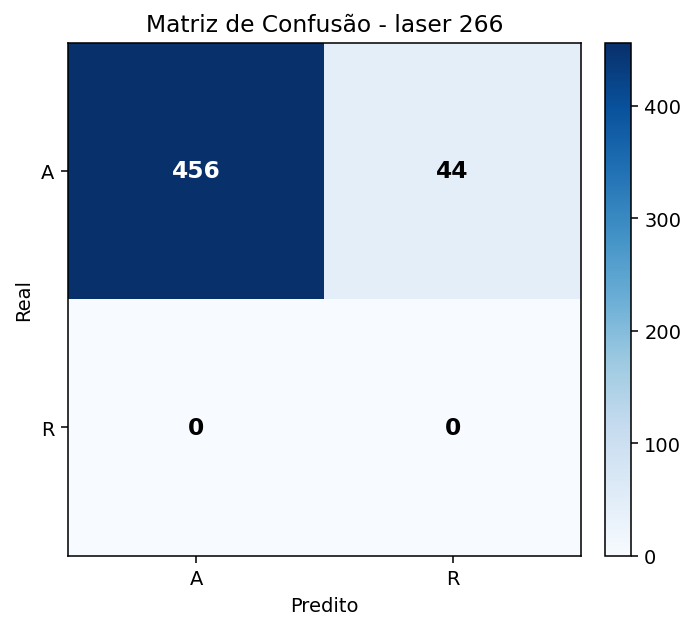

In [5]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# =========================================================
# TESTE LOCAL DO MODELO SALVO - SEM TREINAR E SEM SALVAR
# =========================================================

laser = 266
model_path = Path(proj_root) / 'models' / 'models_groupkfold' / f'laser{laser}' / 'snv_svm_linear.joblib'
dataset_path = Path(proj_root) / 'dataset' / f'merged_inoa_full_data_{laser}.dat'

extra_a_labels_266 = {
    'C_Pilao_sample',
    'C_Evolutto_sample',
    'C_Do_Ponto_sample',
    'C_America_sample',
    'C_Coamo_sample',
}

print(f'Carregando modelo: {model_path}')
pipe = joblib.load(model_path)

print(f'Lendo dataset: {dataset_path}')
df = pd.read_csv(dataset_path, sep=';', header=None, low_memory=False)
y_raw = df.iloc[0, 1:].astype(str).to_numpy()
X_full = df.iloc[1:, 1:].to_numpy(dtype=float).T

mask = np.array([label in extra_a_labels_266 for label in y_raw])
X_test = X_full[mask]
y_test_raw = y_raw[mask]
y_true = np.array(['A'] * len(y_test_raw))

print(f'Total de amostras selecionadas: {len(X_test)}')
print(f'Rótulos encontrados: {sorted(set(y_test_raw))}')

if len(X_test) == 0:
    raise ValueError('Nenhuma amostra encontrada para os rótulos extra_a_labels_266.')

# O pipeline salvo já contém o pré-processamento SNV usado no treino.
y_pred = pipe.predict(X_test)

resultados = pd.DataFrame({
    'sample_name': y_test_raw,
    'y_true': y_true,
    'y_pred': y_pred,
})

print('\nPrimeiras 15 predições:')
print(resultados.head(15).to_string(index=False))

print('\nDistribuição das predições:')
print(pd.Series(y_pred).value_counts().to_string())

print('\nResultados agregados:')
print(f'Acurácia: {accuracy_score(y_true, y_pred):.4f}')
print('Matriz de confusão [A, R]:')
print(confusion_matrix(y_true, y_pred, labels=['A', 'R']))
print('\nRelatório de classificação:')
print(classification_report(y_true, y_pred, labels=['A', 'R'], zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=['A', 'R'])
fig, ax = plt.subplots(figsize=(5.2, 4.6), dpi=140)
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['A', 'R'])
ax.set_yticklabels(['A', 'R'])
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão - laser 266')
threshold = cm.max() / 2 if cm.max() else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            f'{cm[i, j]}',
            ha='center',
            va='center',
            color='white' if cm[i, j] > threshold else 'black',
            fontsize=12,
            fontweight='bold',
        )
plt.tight_layout()
plt.show()
